In [4]:
import re
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

def parse_time(time_str):
    """Convert time string in format H:MM:SS to total seconds"""
    hours, minutes, seconds = map(int, time_str.split(':'))
    return hours * 3600 + minutes * 60 + seconds

def extract_eta_from_logs(filename):
    eta_times = []
    # Regular expression to match ETA: H:MM:SS
    eta_pattern = r'ETA: (\d+:\d+:\d+)'
    
    with open(filename, 'r') as f:
        for line in f:
            match = re.search(eta_pattern, line)
            if match:
                time_str = match.group(1)
                seconds = parse_time(time_str)
                eta_times.append(seconds)
    
    return eta_times

def plot_eta_over_time(eta_times):
    # Create time points (x-axis)
    time_points = np.arange(len(eta_times))
    
    # Convert seconds back to minutes for better visualization
    eta_minutes = [t/60 for t in eta_times]
    
    plt.figure(figsize=(10, 6))
    plt.plot(time_points, eta_minutes, 'b-', linewidth=2)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.title('Estimated Time Remaining Over Time')
    plt.xlabel('Log Entry Number')
    plt.ylabel('ETA (minutes)')
    
    # Add some padding to the y-axis
    plt.margins(y=0.1)
    
    # Format y-axis ticks as HH:MM
    def minutes_to_hhmm(x, pos):
        hours = int(x // 60)
        minutes = int(x % 60)
        return f'{hours}:{minutes:02d}'
    
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(minutes_to_hhmm))
    
    plt.tight_layout()
    plt.show()

def main():
    # Replace 'log_file.txt' with your actual log file name
    filename = '/home/jmyslinski/random_stuff/PBRJ/src/14.log'
    eta_times = extract_eta_from_logs(filename)
    plot_eta_over_time(eta_times)


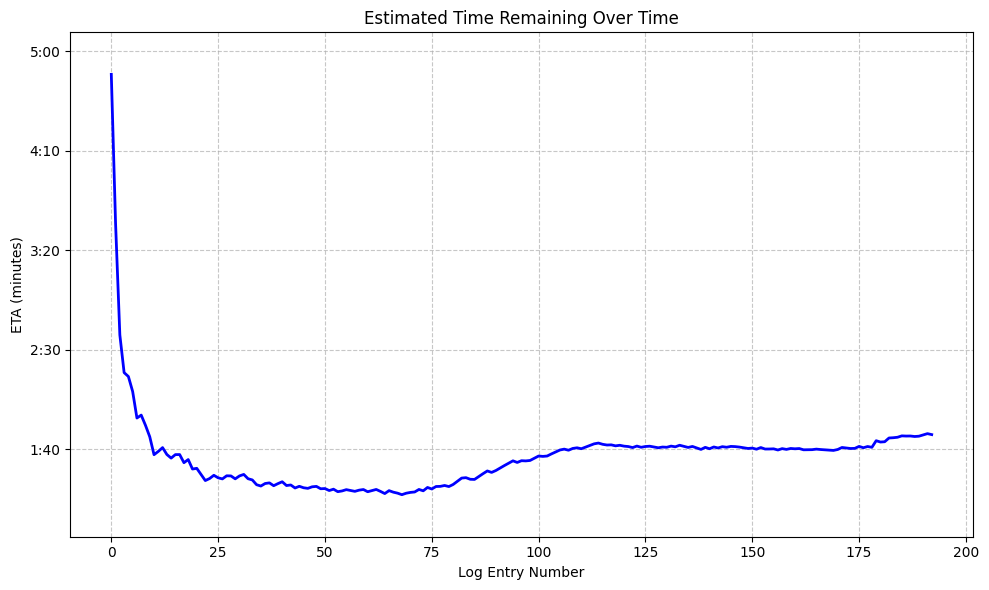

In [5]:
main()